In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Matplotlib is building the font cache; this may take a moment.


In [ ]:
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.unicode_minus"] = False

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 150)


In [19]:
df = pd.read_csv("../dataset/vietnam_real_estate_fnl.csv")
if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

print("Số dòng, số cột:", df.shape)
df.head()

Số dòng, số cột: (10000, 19)


,name,description,property_type_name,province_name,district_name,ward_name,street_name,project_name,price,area,floor_count,frontage_width,house_depth,road_width,bedroom_count,bathroom_count,house_direction,balcony_direction,published_at
0,"Bán đất Thanh Đàm, ô tô vào nhà, cách phố 15m,...","Bán đất Thanh Đàm, ô tô vào nhà, cách phố 15m,...",Nhà,Hà Nội,Hoàng Mai,Thanh Trì,Thanh Đàm,NaN,1.085000e+10,70.0,NaN,5.0,14.0,NaN,NaN,NaN,NaN,NaN,2025-06-24T07:19:17.785000
1,"Lô góc KĐT Bắc Châu Giang, 97m2, chân 34 tòa c...","Thông tin nổi bật: Diện tích: 97m², mặt tiền r...",Biệt thự/Nhà liền kề,Hà Nam,Phủ Lý,Lam Hạ,NaN,Sun Urban City Hà Nam,NaN,97.0,4.0,9.0,NaN,NaN,4.0,3.0,NaN,NaN,2025-10-21T14:34:19.757000
2,"Siêu rẻ. Bán đất diện tích 105m2, mặt đường Ph...",Thông tin chi tiết: - Vị trí: Mặt tiền đường P...,Đất,Đà Nẵng,Ngũ Hành Sơn,Mỹ An,Phan Tôn,NaN,1.950000e+10,105.0,NaN,5.0,NaN,5.5,NaN,NaN,NaN,NaN,2025-10-16T16:20:41.601000
3,"Bán tòa CHDV Nguyễn Thị Minh Khai, Q1 - TN: 72...",Cam Kết: Thông tin thật - Nhà còn bán - Pháp l...,Nhà,Hồ Chí Minh,1,Đa Kao,Nguyễn Thị Minh Khai,NaN,1.900000e+10,72.0,NaN,5.7,NaN,NaN,NaN,NaN,Đông Bắc,NaN,2025-06-19T02:45:17.993000
4,Bán Đất Tặng Nhà 2 Tầng Mặt Tiền Đường Lê Quan...,Bán Đất Tặng Nhà 2 Tầng Mặt Tiền Đường Lê Quan...,Đất,Đà Nẵng,Ngũ Hành Sơn,Mỹ An,Lê Quang Đạo,NaN,4.600000e+10,128.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-10-29T05:40:51.815000


In [20]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   name                9995 non-null   object 
 1   description         9995 non-null   object 
 2   property_type_name  10000 non-null  object 
 3   province_name       10000 non-null  object 
 4   district_name       9703 non-null   object 
 5   ward_name           8570 non-null   object 
 6   street_name         6088 non-null   object 
 7   project_name        2763 non-null   object 
 8   price               9227 non-null   float64
 9   area                10000 non-null  float64
 10  floor_count         2469 non-null   float64
 11  frontage_width      5196 non-null   float64
 12  house_depth         261 non-null    float64
 13  road_width          2002 non-null   float64
 14  bedroom_count       5416 non-null   float64
 15  bathroom_count      5067 non-null   float64
 16  house

In [21]:
df.describe(include=[np.number]).T

,count,mean,std,min,25%,50%,75%,max
price,9227.0,1.407673e+10,2.921538e+10,7500000.00,4.100000e+09,7.400000e+09,1.388900e+10,1.137000e+12
area,10000.0,2.096100e+02,1.513426e+03,3.40,5.500000e+01,8.000000e+01,1.200000e+02,7.881340e+04
floor_count,2469.0,3.900770e+00,1.621709e+00,1.00,3.000000e+00,4.000000e+00,5.000000e+00,1.100000e+01
frontage_width,5196.0,7.530735e+00,1.008613e+01,2.00,4.200000e+00,5.000000e+00,7.300000e+00,3.000000e+02
house_depth,261.0,2.193188e+01,1.698645e+01,3.58,1.295000e+01,1.860000e+01,2.400000e+01,1.375600e+02
road_width,2002.0,9.627522e+00,1.565014e+01,1.50,4.000000e+00,6.000000e+00,1.050000e+01,4.000000e+02
bedroom_count,5416.0,3.404911e+00,2.673941e+00,1.00,2.000000e+00,3.000000e+00,4.000000e+00,5.600000e+01
bathroom_count,5067.0,3.174857e+00,2.798506e+00,1.00,2.000000e+00,2.000000e+00,4.000000e+00,6.600000e+01


In [22]:
df.describe(include=["object"]).T

,count,unique,top,freq
name,9995,9987,"Bán nhà Phan Văn Trị P12 Bình Thạnh, 4x8m vuôn...",2
description,9995,9990,Chung cư hoa hậu Cánh Đồng Mơ 624 Minh Khai | ...,2
property_type_name,10000,5,Nhà,4573
province_name,10000,55,Hồ Chí Minh,3707
district_name,9703,298,Thủ Đức,591
ward_name,8570,1100,14,133
street_name,6088,1700,Lạc Long Quân,69
project_name,2763,1231,Vinhomes Ocean Park 2 – The Empire,56
house_direction,3051,12,Đông Nam,403
balcony_direction,1555,12,Đông Nam,240


In [23]:
missing = df.isna().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
missing_df = missing_df[missing_df["missing_count"] > 0]
missing_df

,missing_count,missing_pct
house_depth,9739,97.39
balcony_direction,8445,84.45
road_width,7998,79.98
floor_count,7531,75.31
project_name,7237,72.37
house_direction,6949,69.49
bathroom_count,4933,49.33
frontage_width,4804,48.04
bedroom_count,4584,45.84
street_name,3912,39.12


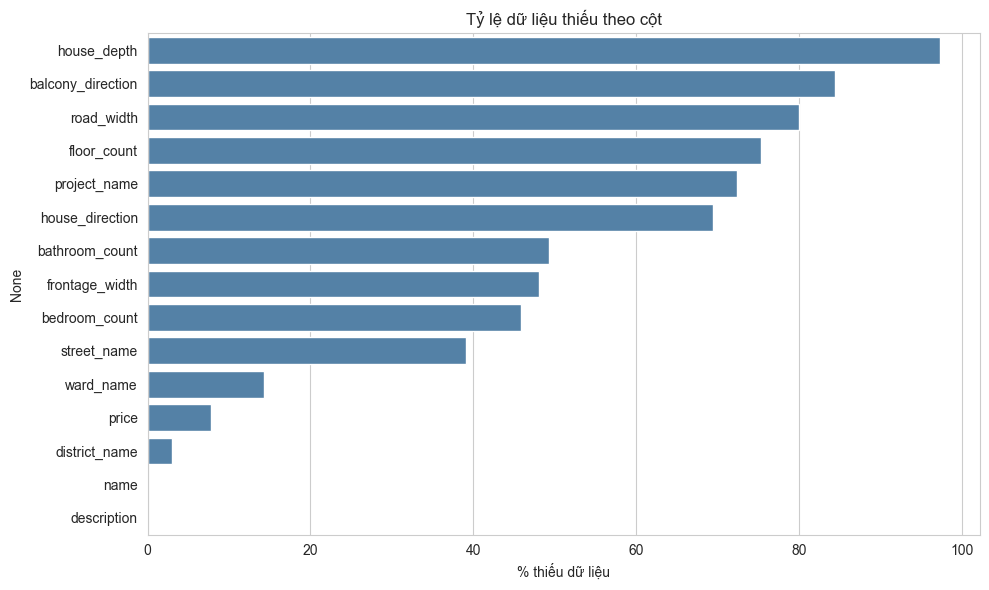

In [24]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x=missing_df["missing_pct"], y=missing_df.index, ax=ax, color="steelblue")
ax.set_xlabel("% thiếu dữ liệu")
ax.set_title("Tỷ lệ dữ liệu thiếu theo cột")
plt.tight_layout()
plt.show()

In [25]:
df["published_at"] = pd.to_datetime(df["published_at"], errors="coerce")

df["price_per_m2"] = df["price"] / df["area"]
df.loc[(df["area"] <= 0) | (df["price"] <= 0), "price_per_m2"] = np.nan

# đơn vị: tỷ VND cho giá, để dễ đọc biểu đồ
df["price_ty"] = df["price"] / 1e9

df[["price", "price_ty", "area", "price_per_m2"]].describe()

,price,price_ty,area,price_per_m2
count,9.227000e+03,9227.000000,10000.000000,9.227000e+03
mean,1.407673e+10,14.076734,209.610012,1.347099e+08
std,2.921538e+10,29.215379,1513.426284,1.317813e+08
min,7.500000e+06,0.007500,3.400000,4.761905e+04
25%,4.100000e+09,4.100000,55.000000,5.150452e+07
50%,7.400000e+09,7.400000,80.000000,9.722222e+07
75%,1.388900e+10,13.889000,120.000000,1.861034e+08
max,1.137000e+12,1137.000000,78813.400000,4.676471e+09


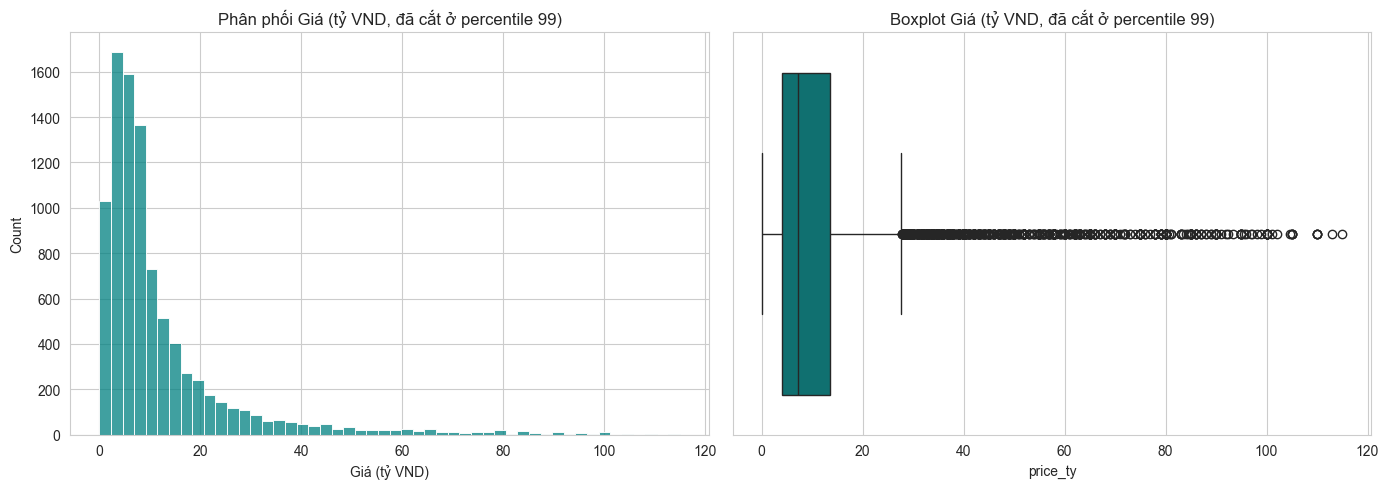

Giá trung vị: 7.4 tỷ
Giá trung bình: 14.08 tỷ


In [26]:
valid_price = df["price_ty"].dropna()
valid_price_capped = valid_price[valid_price <= valid_price.quantile(0.99)]  # bỏ bớt outlier cực đoan để dễ nhìn

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(valid_price_capped, bins=50, ax=axes[0], color="teal")
axes[0].set_title("Phân phối Giá (tỷ VND, đã cắt ở percentile 99)")
axes[0].set_xlabel("Giá (tỷ VND)")

sns.boxplot(x=valid_price_capped, ax=axes[1], color="teal")
axes[1].set_title("Boxplot Giá (tỷ VND, đã cắt ở percentile 99)")
plt.tight_layout()
plt.show()

print("Giá trung vị:", valid_price.median(), "tỷ")
print("Giá trung bình:", valid_price.mean().round(2), "tỷ")


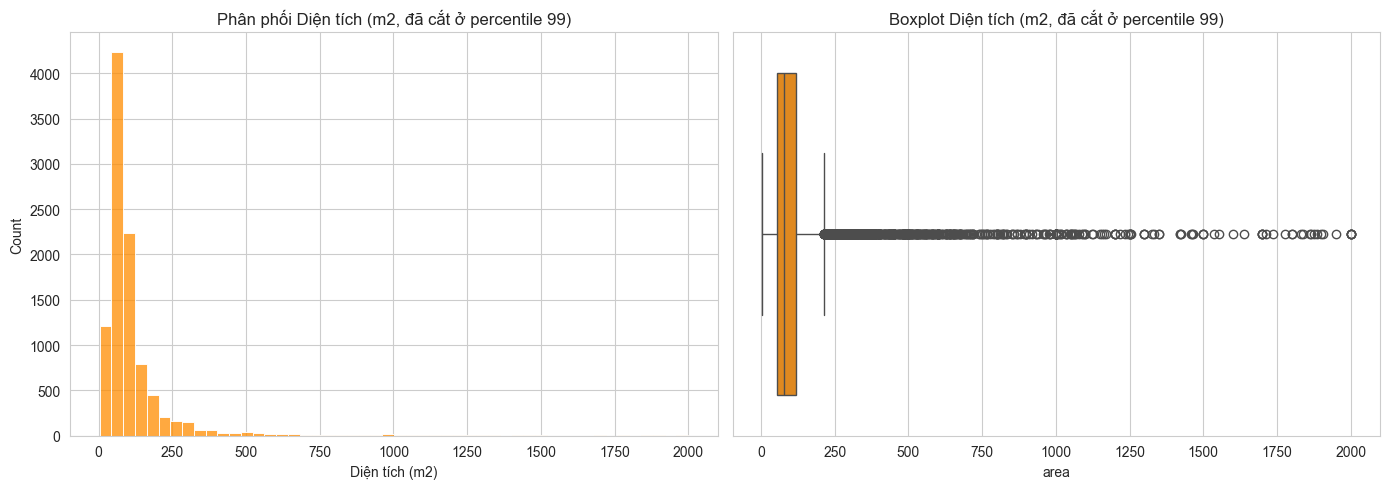

In [27]:
valid_area = df["area"].dropna()
valid_area_capped = valid_area[valid_area <= valid_area.quantile(0.99)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(valid_area_capped, bins=50, ax=axes[0], color="darkorange")
axes[0].set_title("Phân phối Diện tích (m2, đã cắt ở percentile 99)")
axes[0].set_xlabel("Diện tích (m2)")

sns.boxplot(x=valid_area_capped, ax=axes[1], color="darkorange")
axes[1].set_title("Boxplot Diện tích (m2, đã cắt ở percentile 99)")
plt.tight_layout()
plt.show()


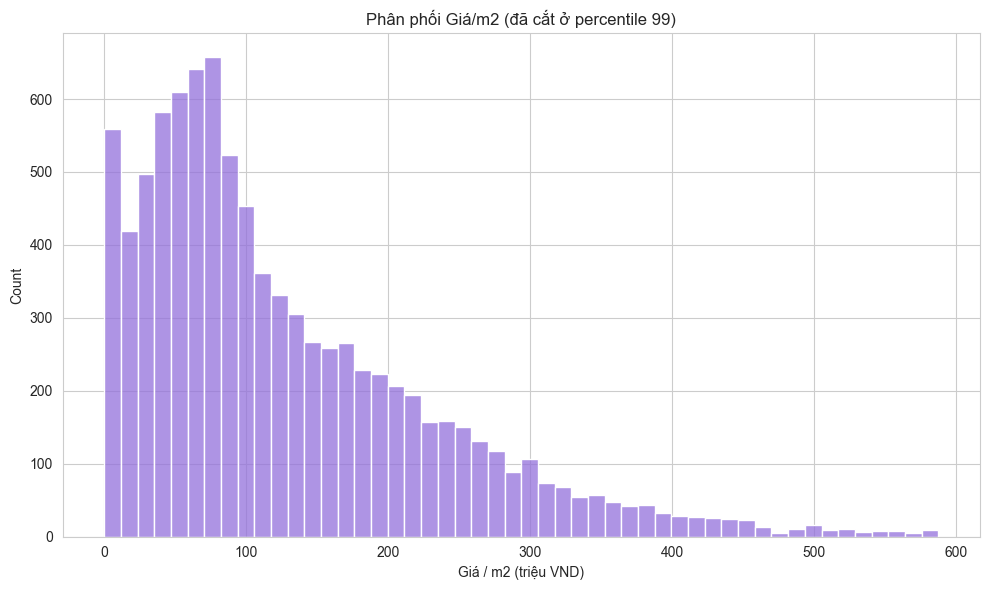

Giá/m2 trung vị: 97.2 triệu/m2


In [28]:
valid_ppm2 = df["price_per_m2"].dropna()
valid_ppm2_capped = valid_ppm2[valid_ppm2 <= valid_ppm2.quantile(0.99)]

fig, ax = plt.subplots(figsize=(10, 6))
sns.histplot(valid_ppm2_capped / 1e6, bins=50, color="mediumpurple")
ax.set_xlabel("Giá / m2 (triệu VND)")
ax.set_title("Phân phối Giá/m2 (đã cắt ở percentile 99)")
plt.tight_layout()
plt.show()

print("Giá/m2 trung vị:", (valid_ppm2.median() / 1e6).round(1), "triệu/m2")


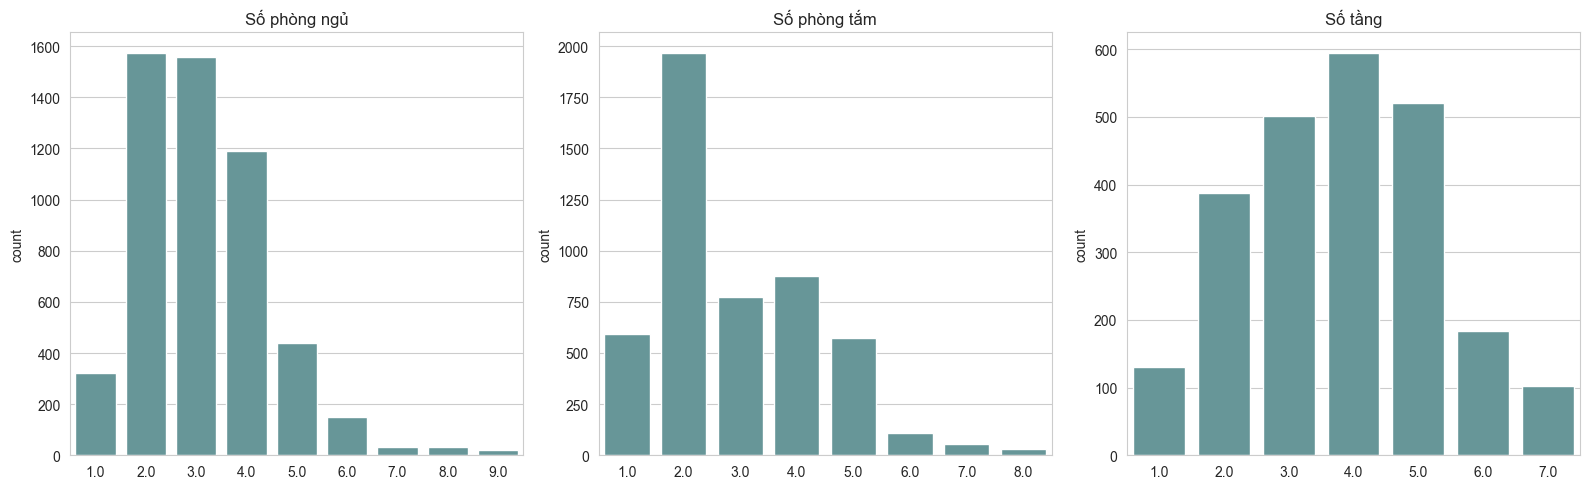

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, col, title in zip(
    axes,
    ["bedroom_count", "bathroom_count", "floor_count"],
    ["Số phòng ngủ", "Số phòng tắm", "Số tầng"],
):
    vc = df[col].dropna()
    sns.countplot(x=vc[vc <= vc.quantile(0.98)], ax=ax, color="cadetblue")
    ax.set_title(title)
    ax.set_xlabel("")
plt.tight_layout()
plt.show()


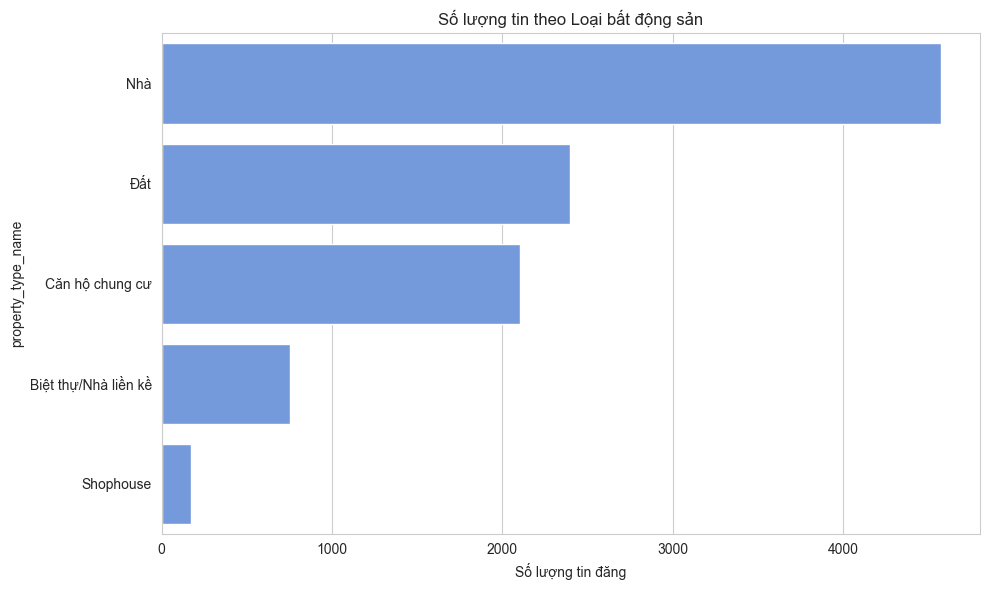

In [30]:
type_counts = df["property_type_name"].value_counts()
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x=type_counts.values, y=type_counts.index, ax=ax, color="cornflowerblue")
ax.set_xlabel("Số lượng tin đăng")
ax.set_title("Số lượng tin theo Loại bất động sản")
plt.tight_layout()
plt.show()


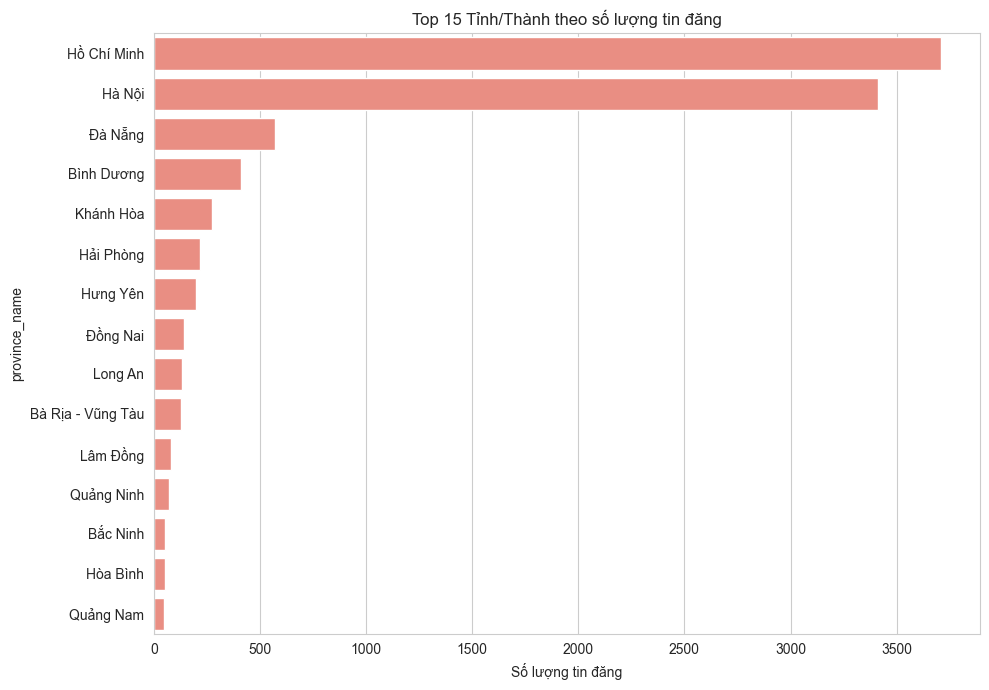

In [31]:
province_counts = df["province_name"].value_counts().head(15)
fig, ax = plt.subplots(figsize=(10, 7))
sns.barplot(x=province_counts.values, y=province_counts.index, ax=ax, color="salmon")
ax.set_xlabel("Số lượng tin đăng")
ax.set_title("Top 15 Tỉnh/Thành theo số lượng tin đăng")
plt.tight_layout()
plt.show()


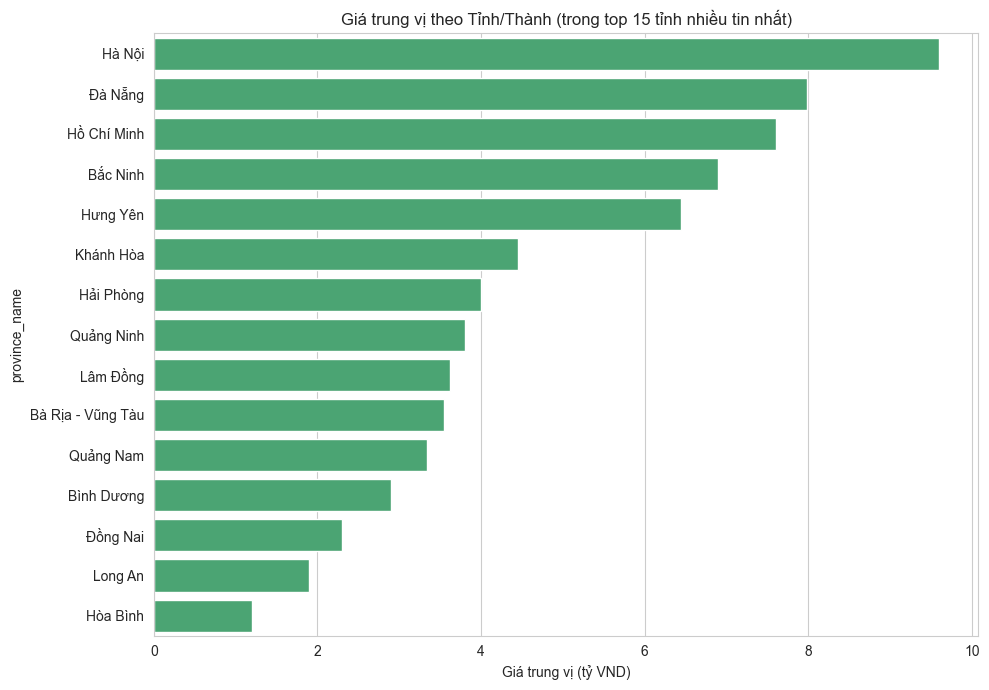

In [32]:
top_provinces = province_counts.index
price_by_province = (
    df[df["province_name"].isin(top_provinces)]
    .groupby("province_name")["price_ty"]
    .median()
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(10, 7))
sns.barplot(x=price_by_province.values, y=price_by_province.index, ax=ax, color="mediumseagreen")
ax.set_xlabel("Giá trung vị (tỷ VND)")
ax.set_title("Giá trung vị theo Tỉnh/Thành (trong top 15 tỉnh nhiều tin nhất)")
plt.tight_layout()
plt.show()


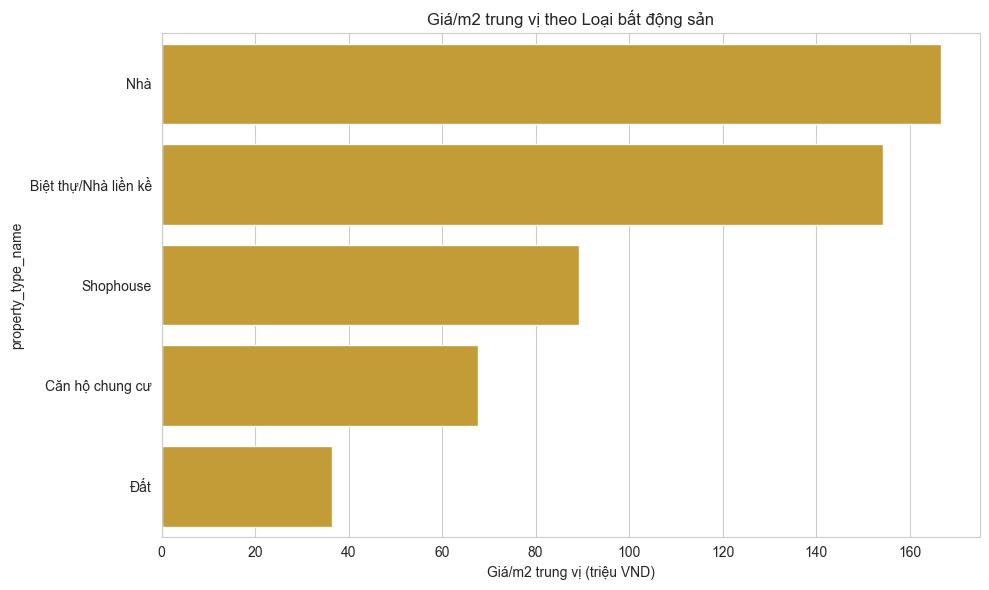

In [33]:
ppm2_by_type = (
    df.groupby("property_type_name")["price_per_m2"]
    .median()
    .sort_values(ascending=False) / 1e6
)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x=ppm2_by_type.values, y=ppm2_by_type.index, ax=ax, color="goldenrod")
ax.set_xlabel("Giá/m2 trung vị (triệu VND)")
ax.set_title("Giá/m2 trung vị theo Loại bất động sản")
plt.tight_layout()
plt.show()


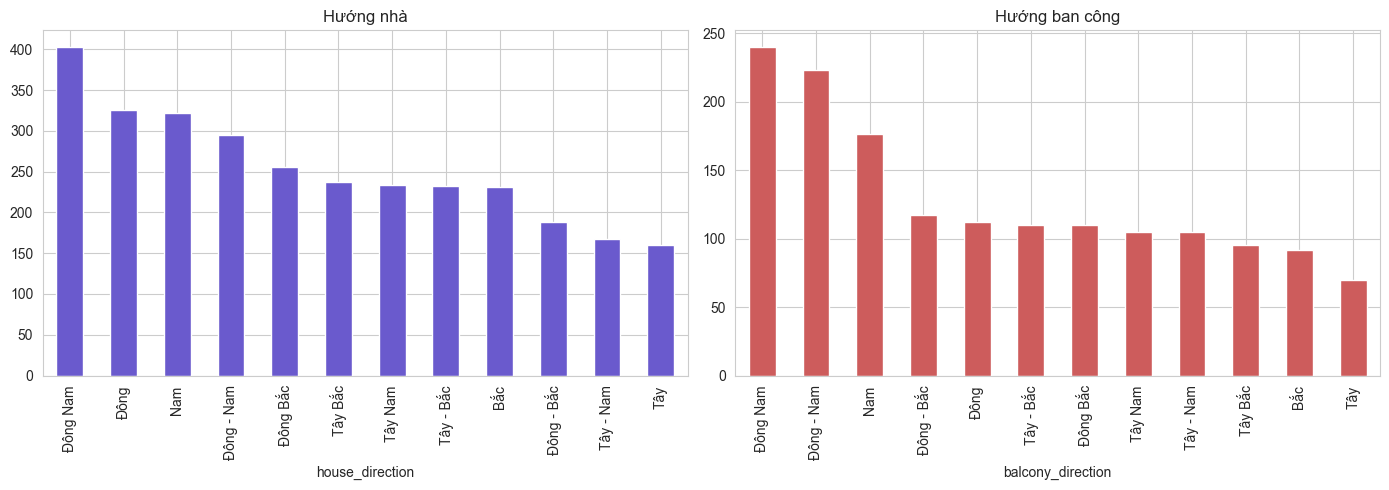

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
df["house_direction"].value_counts().plot(kind="bar", ax=axes[0], color="slateblue")
axes[0].set_title("Hướng nhà")
df["balcony_direction"].value_counts().plot(kind="bar", ax=axes[1], color="indianred")
axes[1].set_title("Hướng ban công")
plt.tight_layout()
plt.show()


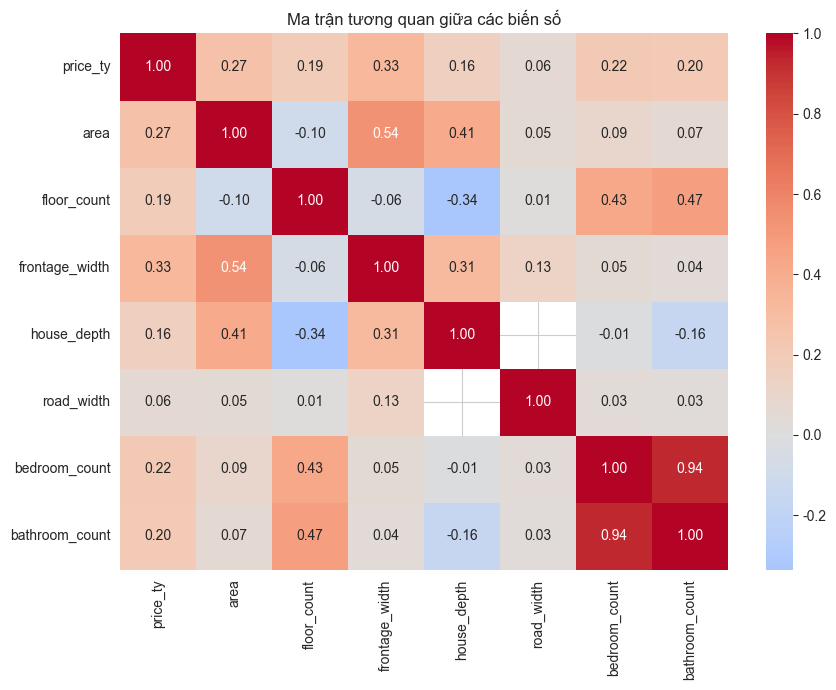

In [35]:
num_cols = ["price_ty", "area", "floor_count", "frontage_width",
            "house_depth", "road_width", "bedroom_count", "bathroom_count"]

corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Ma trận tương quan giữa các biến số")
plt.tight_layout()
plt.show()


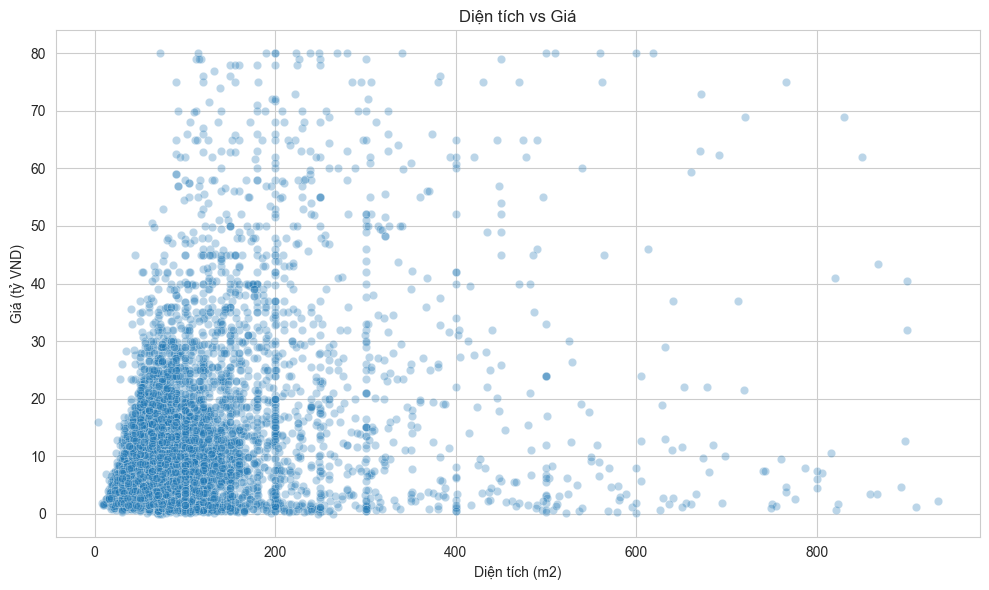

In [36]:
# Quan hệ Diện tích vs Giá (đã cắt outlier để dễ nhìn)
plot_df = df[(df["area"] <= df["area"].quantile(0.98)) & (df["price_ty"] <= df["price_ty"].quantile(0.98))]

fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(data=plot_df, x="area", y="price_ty", alpha=0.3, ax=ax)
ax.set_xlabel("Diện tích (m2)")
ax.set_ylabel("Giá (tỷ VND)")
ax.set_title("Diện tích vs Giá")
plt.tight_layout()
plt.show()


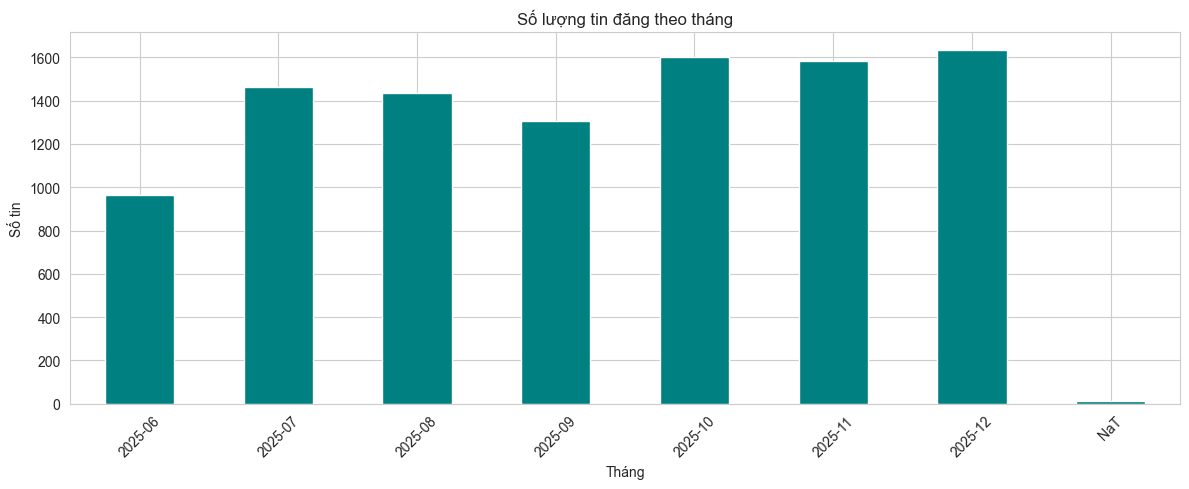

In [37]:
df["published_month"] = df["published_at"].dt.to_period("M").astype(str)

posts_by_month = df["published_month"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(12, 5))
posts_by_month.plot(kind="bar", ax=ax, color="teal")
ax.set_title("Số lượng tin đăng theo tháng")
ax.set_xlabel("Tháng")
ax.set_ylabel("Số tin")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [38]:
def iqr_outlier_bounds(series):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    return q1 - 1.5 * iqr, q3 + 1.5 * iqr

for col in ["price_ty", "area", "price_per_m2"]:
    s = df[col].dropna()
    low, high = iqr_outlier_bounds(s)
    n_outliers = ((s < low) | (s > high)).sum()
    print(f"{col}: ngưỡng [{low:.2f}, {high:.2f}], số outlier = {n_outliers} ({n_outliers/len(s)*100:.1f}%)")


price_ty: ngưỡng [-10.58, 28.57], số outlier = 914 (9.9%)
area: ngưỡng [-42.50, 217.50], số outlier = 1005 (10.1%)
price_per_m2: ngưỡng [-150393860.20, 388001833.36], số outlier = 352 (3.8%)


Xử lý giá trị thiếu:

Các cột có tỷ lệ thiếu quá cao như house_depth, balcony_direction, road_width có thể cân nhắc loại bỏ nếu không phục vụ cho mô hình dự đoán.

Các cột như price, district_name, bedroom_count cần được xử lý khéo léo (điền giá trị phù hợp bằng Median/Mode hoặc loại bỏ các dòng thiếu price nếu đang làm bài toán dự đoán giá).

Xử lý Outlier (Giá trị ngoại lai):

Cần lọc bỏ các giá trị diện tích hoặc giá bất thường (ví dụ: diện tích vài m2 nhưng giá hàng chục tỷ, hoặc diện tích lên tới vài chục nghìn m2) để mô hình học máy hoạt động chính xác hơn.

Mã hóa dữ liệu phân loại (Categorical Encoding): Chuyển đổi các cột như province_name, property_type_name, district_name sang dạng số để đưa vào các thuật toán Machine Learning.